In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("./placement-dataset.csv")
df.head(10)

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
5,5,7.1,48.0,1
6,6,5.7,143.0,0
7,7,5.0,63.0,0
8,8,6.1,156.0,0
9,9,5.1,66.0,0


In [6]:
df = df.drop("Unnamed: 0", axis=1)
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [8]:
df.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_24940\3185445037.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["cgpa"])
C:\Users\hp\AppData\Local\Temp\ipykernel_24940\3185445037.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["iq"])


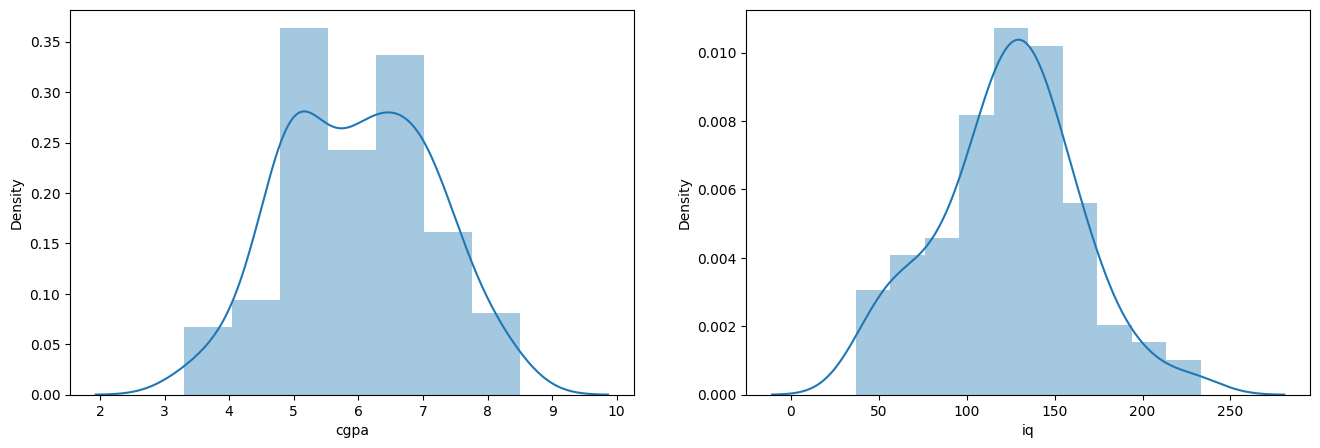

In [10]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.distplot(df["cgpa"])
plt.subplot(1, 2, 2)
sns.distplot(df["iq"])
plt.show()

In [11]:
df["iq"].describe()

count    100.000000
mean     123.580000
std       39.944198
min       37.000000
25%      101.500000
50%      127.500000
75%      149.000000
max      233.000000
Name: iq, dtype: float64

<Axes: ylabel='iq'>

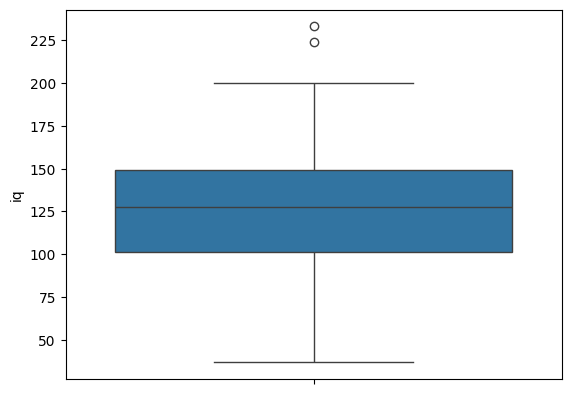

In [12]:
sns.boxplot(df["iq"])

In [13]:
# iqr
p25 = df["iq"].quantile(0.25)
p75 = df["iq"].quantile(0.75)
iqr = p75 - p25

In [14]:
upper_limit = p75 + 1.5 * iqr
lower_limit = p25 - 1.5 * iqr

print("upper limit: ", upper_limit)
print("lower limit: ", lower_limit)

upper limit:  220.25
lower limit:  30.25


In [15]:
# outlier finding -> Filtering

df[df["iq"] > upper_limit]

,cgpa,iq,placement
16,5.2,224.0,0
50,3.5,233.0,0


In [17]:
# Trimming
df_trimmed = df[df["iq"] < upper_limit]
df_trimmed.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [18]:
df_trimmed.shape

(98, 3)

In [19]:
df.shape

(100, 3)

C:\Users\hp\AppData\Local\Temp\ipykernel_24940\3803288525.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["iq"])
C:\Users\hp\AppData\Local\Temp\ipykernel_24940\3803288525.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_trimmed["iq"])


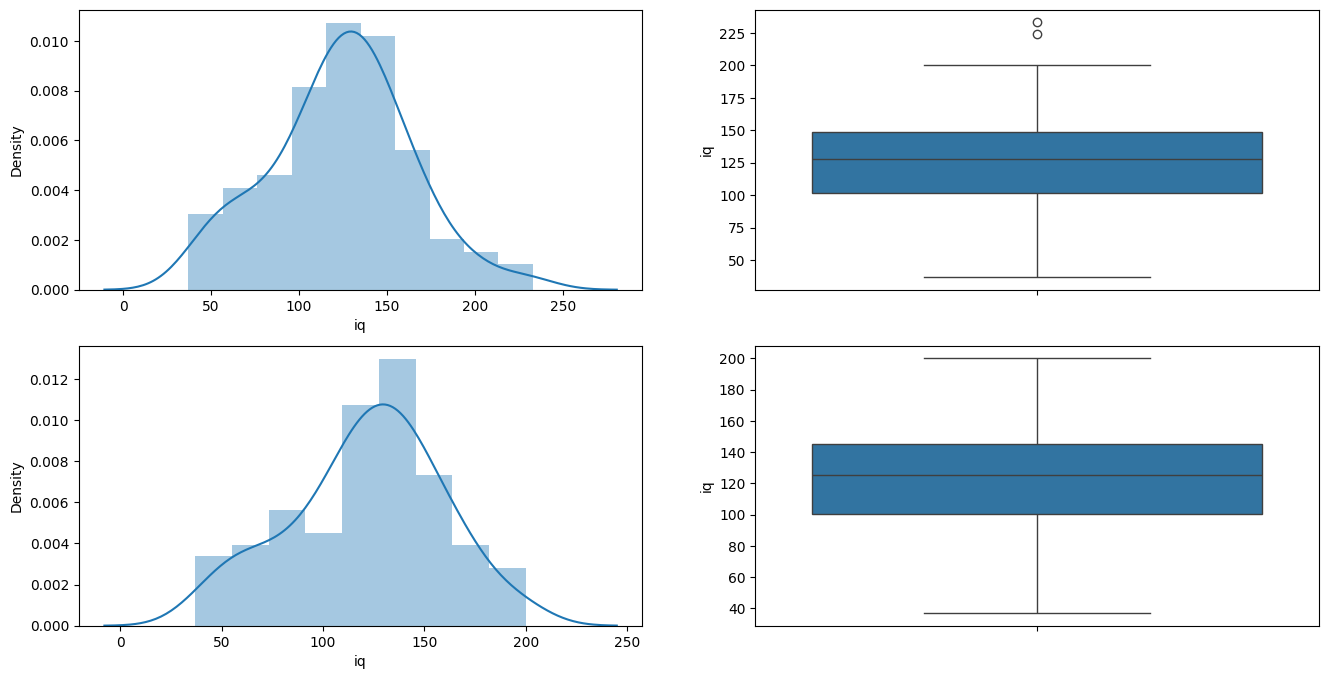

In [22]:
# comparison of trimmed and original data
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.distplot(df["iq"])
plt.subplot(2, 2, 2)
sns.boxplot(df["iq"])

plt.subplot(2, 2, 3)
sns.distplot(df_trimmed["iq"])
plt.subplot(2, 2, 4)
sns.boxplot(df_trimmed["iq"])
plt.show()

In [23]:
# capping
df_capped = df.copy()
df_capped["iq"] = np.where(
    df_capped["iq"] > upper_limit, upper_limit, np.where(
        df_capped["iq"] < lower_limit, lower_limit, df_capped["iq"]
     )
    )


In [24]:
df.shape

(100, 3)

In [25]:
df_capped.shape

(100, 3)

C:\Users\hp\AppData\Local\Temp\ipykernel_24940\340581077.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["iq"])
C:\Users\hp\AppData\Local\Temp\ipykernel_24940\340581077.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_capped["iq"])


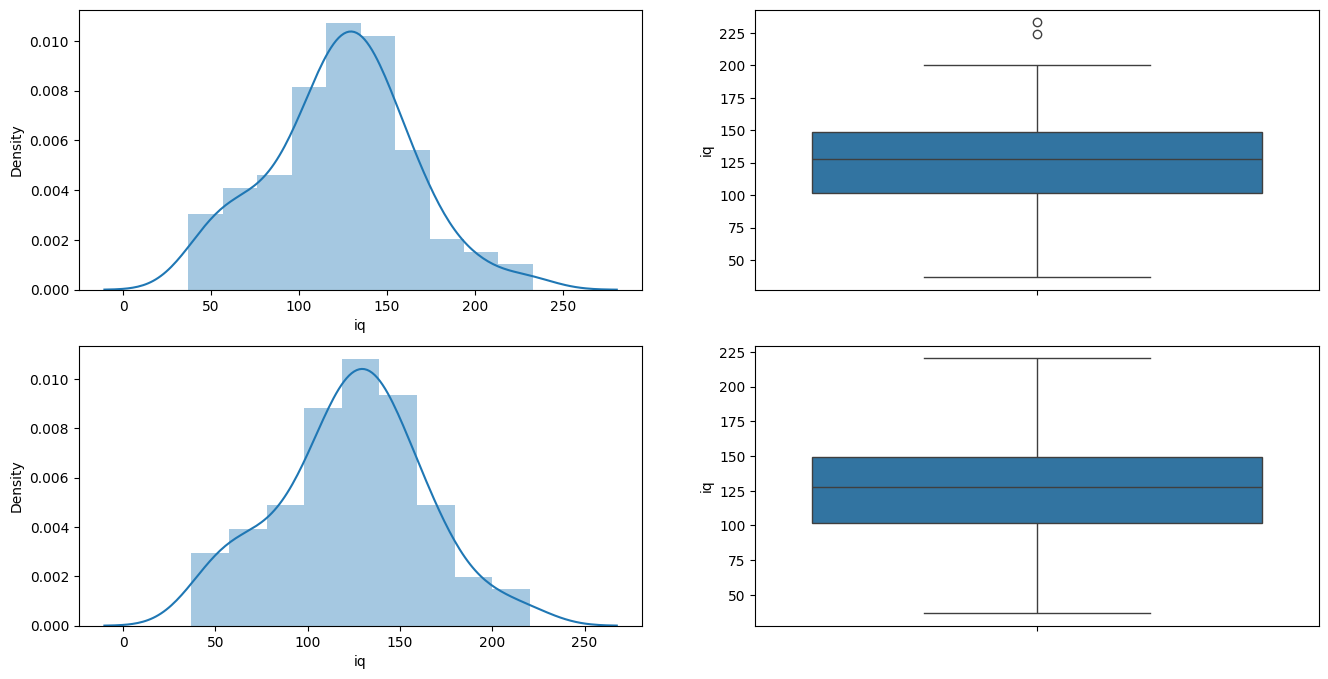

In [26]:
# comparison of trimmed and original data
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.distplot(df["iq"])
plt.subplot(2, 2, 2)
sns.boxplot(df["iq"])

plt.subplot(2, 2, 3)
sns.distplot(df_capped["iq"])
plt.subplot(2, 2, 4)
sns.boxplot(df_capped["iq"])
plt.show()